# Congressional civility & "toxicity" — interactive explorer

Explore changes in comity and conflict language in the U.S. Congressional Record,
**1873–2026**, and interact with the underlying data and plots.

**Data**
- 1873–2017: Stanford *hein* corpus (Gentzkow–Shapiro–Taddy), speaker-segmented with party.
- 2017–present: GovInfo CREC (whole-day package zips), segmented into speaker turns; party
  from MODS `congMember@party`.

**What we measure** (all rates are per 1,000 words, split by speaker party):
- *Formulaic courtesy* — parliamentary address/deference ("the gentleman from").
- *Gratitude / praise* — thanks, commendation, appreciation, or explicit respect.
- *Bipartisan cooperation* — cross-aisle work, common ground, and bipartisan spirit.
- *Personal disrespect / attack* — a high-precision insult and attack lexicon.
- *Misconduct allegations* — corruption, fraud, perjury, obstruction, and similar allegation
  language; this is **not evidence that misconduct occurred**.
- *High-precision profanity* — genuine curse/obscene forms, excluding neutral topical terms.
- *Identity slurs* — a separate exact-match diagnostic requiring quotation/context review.
- *Ideological labels* — tracked separately, not automatically treated as disrespect.
- *Cross-party reference context* — out-party references plus comity, disrespect, or misconduct
  terms nearby, reported both per 1,000 words and per 100 reference contexts. Proximity does not
  prove that the phrase targets the party.
- *Sentiment / "toxicity"* — VADER sentence-level compound + negative-affect share (see the
  toxicity section below for exactly what this means and how we validate it).

**Keyword matching is usually fuzzy.** Most lexicon terms are matched with morphological variants
(plurals and verb forms: "colleague"→"colleagues", "coward"→"cowards"; irregular plurals like
"gentleman"→"gentlemen"), so recall doesn't hinge on listing every inflection. (OCR noise in the
pre-2011 scanned text is a known residual limitation — see caveats.) Profanity, identity slurs,
and misconduct allegations use exact curated forms to avoid unsafe or ambiguous expansions.

> **On the word "toxicity."** There is no single ground-truth "toxicity" label for a
> 150-year speech corpus. Here *toxicity* is only a shorthand for several disclosed lexical
> signals; it is not a ground-truth label. The measures are transparent and reproducible, but
> they miss sarcasm, quotation, some negation, and target identity. Optional checks below are
> diagnostics, not independent human validation.

In [1]:
import sys, glob
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make the analysis package importable when running from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from analysis.plotting import theme, charts   # shared Substack-style toolkit
from analysis.viz import _by_congress_party, _by_year_chamber_party
theme.apply()

METRICS = ROOT / "data" / "processed" / "metrics" / "civility_metrics.parquet"
assert METRICS.exists(), f"Run `python -m analysis.run aggregate` first; missing {METRICS}"
m = pd.read_parquet(METRICS)
floor = m[m.chamber.isin(["house", "senate"])].copy()
print(f"metrics rows: {len(m)}  | congresses {m.congress.min()}–{m.congress.max()}"
      f" (years {m.year.min()}–{m.year.max()})")
m.head()

metrics rows: 845  | congresses 43–119 (years 1873–2025)


,congress,year,chamber,party,turns,words,formal_courtesy_hits,gratitude_praise_hits,cooperation_hits,hostility_hits,...,outgroup_ref_per_1k,democrat_party_pej_per_1k,directed_comity_per_1k,directed_hostility_per_1k,directed_misconduct_per_1k,outgroup_comity_contexts_per_100_refs,outgroup_hostility_contexts_per_100_refs,outgroup_misconduct_contexts_per_100_refs,mean_sentiment,mean_neg_share
0,43,1873,house,D,16844,1545776,2933,16,0,23,...,0.235480,0.0,0.025877,0.001294,0.004528,3.296703,0.0,0.274725,None,None
1,43,1873,house,I,23,8993,11,0,0,0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,None,None
2,43,1873,house,R,36888,3531564,6234,34,0,35,...,0.167631,0.0,0.020104,0.000283,0.001982,4.222973,0.0,0.337838,None,None
3,43,1873,house,other,4712,533995,779,4,0,4,...,0.088016,0.0,0.011236,0.000000,0.000000,4.255319,0.0,0.000000,None,None
4,43,1873,other,D,90,6188,10,0,0,0,...,0.323206,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,None,None


## Provenance and coverage

These artifacts are generated by the production pipeline. Source overlap and validation tables
appear only after those stages have actually run.

In [2]:
SOURCE_META = ROOT / "data" / "processed" / "coverage" / "source_metadata.json"
COVERAGE = ROOT / "data" / "processed" / "coverage" / "turn_coverage.parquet"
if SOURCE_META.exists():
    print(json.dumps(json.loads(SOURCE_META.read_text()), indent=2))
if COVERAGE.exists():
    coverage = pd.read_parquet(COVERAGE)
    display(coverage.tail(12)) if "display" in globals() else print(coverage.tail(12).to_string())

CALIBRATION = ROOT / "data" / "processed" / "calibration" / "calibration_summary.csv"
if CALIBRATION.exists():
    calibration = pd.read_csv(CALIBRATION)
    display(calibration) if "display" in globals() else print(calibration.to_string(index=False))
else:
    print("Overlap calibration has not been generated yet.")

VALIDATION_REPORT = ROOT / "data" / "processed" / "validation" / "precision_recall.csv"
if VALIDATION_REPORT.exists():
    validation = pd.read_csv(VALIDATION_REPORT)
    display(validation) if "display" in globals() else print(validation.to_string(index=False))
else:
    print("Model-assisted validation has not been completed yet.")

{
  "sources": [
    {
      "source": "govinfo",
      "min_congress": 103,
      "max_congress": 119,
      "min_year": 1993,
      "max_year": 2025,
      "rows": 201
    },
    {
      "source": "hein_bound",
      "min_congress": 43,
      "max_congress": 96,
      "min_year": 1873,
      "max_year": 1979,
      "rows": 590
    },
    {
      "source": "hein_daily",
      "min_congress": 97,
      "max_congress": 114,
      "min_year": 1981,
      "max_year": 2015,
      "rows": 197
    }
  ],
  "primary_boundary_year": 2017,
  "primary_rule": "Hein through Congress 114; GovInfo from Congress 115"
}


,source,congress,year,chamber,total_turns,total_words,procedural_turns,procedural_words,nonprocedural_turns,nonprocedural_words,analysis_party_turns,analysis_party_words,analysis_party_turn_share,analysis_party_word_share
333,hein_daily,112,2011,extensions,13890,4598635,22,140,13868,4598495,0,0,0.000000,0.000000
334,hein_daily,112,2011,house,74750,12570415,15825,344570,58925,12225845,58124,11985620,0.986406,0.980351
335,hein_daily,112,2011,other,27,5948,15,1265,12,4683,12,4683,1.000000,1.000000
336,hein_daily,112,2011,senate,57233,12276521,23601,300818,33632,11975703,32924,11678903,0.978949,0.975216
337,hein_daily,113,2013,extensions,11892,3917684,0,0,11892,3917684,0,0,0.000000,0.000000
338,hein_daily,113,2013,house,63227,10797327,14500,324614,48727,10472713,47894,10255723,0.982905,0.979280
339,hein_daily,113,2013,other,13,2334,7,657,6,1677,6,1677,1.000000,1.000000
340,hein_daily,113,2013,senate,53016,11226548,22871,318400,30145,10908148,29721,10725963,0.985935,0.983298
341,hein_daily,114,2015,extensions,10973,3342463,6,260,10967,3342203,0,0,0.000000,0.000000
342,hein_daily,114,2015,house,57588,9320332,13112,302966,44476,9017366,43693,8811835,0.982395,0.977207


,metric,paired_cells,positive_paired_cells,pearson,spearman,mean_difference_govinfo_minus_hein,median_hein_to_govinfo_multiplier,log_ratio_iqr,stable_adjustment,recommended_govinfo_to_hein_multiplier
0,cooperation_per_1k,48,48,0.973778,0.967000,-0.009601,1.310864,0.186855,True,1.310864
1,formal_courtesy_per_1k,48,48,0.978171,0.983500,-0.298347,1.387048,0.197049,True,1.387048
2,gratitude_praise_per_1k,48,48,0.954153,0.890686,-0.085148,1.430332,0.242355,True,1.430332
3,hostility_per_1k,48,48,0.907914,0.898611,-0.002540,1.145242,0.179886,True,1.145242
4,misconduct_per_1k,48,48,0.908845,0.886452,0.006980,0.926400,0.170107,True,0.926400
5,outgroup_comity_contexts_per_100_refs,48,48,0.944866,0.915871,-0.737095,1.417839,0.175186,True,1.417839
6,outgroup_hostility_contexts_per_100_refs,48,29,0.682750,0.680648,-0.019329,2.179801,0.685202,False,NaN
7,outgroup_misconduct_contexts_per_100_refs,48,23,0.438815,0.616094,-0.030197,2.473840,0.907762,False,NaN
8,profanity_per_1k,48,48,0.642841,0.766175,-0.000159,0.995854,0.567851,False,NaN


,field,era,source_family,n_coded,tp,fp,fn,precision,recall
0,outparty_target_exists,all,all,784,123,3,59,0.976190,0.675824
1,outparty_target_exists,1873-1900,hein,112,16,0,6,1.000000,0.727273
2,outparty_target_exists,1901-1945,hein,112,14,1,7,0.933333,0.666667
3,outparty_target_exists,1946-1980,hein,112,12,0,9,1.000000,0.571429
4,outparty_target_exists,1981-1993,hein,112,17,0,8,1.000000,0.680000
...,...,...,...,...,...,...,...,...,...
67,identity_slur,1946-1980,hein,112,7,0,1,1.000000,0.875000
68,identity_slur,1981-1993,hein,112,2,0,0,1.000000,1.000000
69,identity_slur,1994-2016,govinfo,112,5,0,1,1.000000,0.833333
70,identity_slur,1994-2016,hein,112,4,0,1,1.000000,0.800000


## 1. Re-aggregate to (Congress, party)

The metrics table is stored at `(congress, chamber, party)` granularity with **raw hit
counts + word totals**, so we can re-aggregate to any grouping while keeping rates
word-weighted (never averaging rates-of-rates).

In [3]:
# Reuse the production aggregation/rate definitions instead of duplicating formulas here.
g = _by_congress_party(floor)
g[g.party.isin(["D","R"])].tail(6)

,congress,year,party,formal_courtesy_hits,gratitude_praise_hits,cooperation_hits,hostility_hits,misconduct_hits,profanity_hits,comity_hits,...,profanity_strong_per_1k,profanity_slurs_per_1k,outgroup_ref_per_1k,democrat_party_pej_per_1k,directed_comity_per_1k,directed_hostility_per_1k,directed_misconduct_per_1k,outgroup_comity_contexts_per_100_refs,outgroup_hostility_contexts_per_100_refs,outgroup_misconduct_contexts_per_100_refs
267,117,2021,D,5656,1619,493,146,1139,136,11405,...,0.004176,0.000085,0.644819,0.000085,0.046527,0.001363,0.002897,1.585833,0.013215,0.013215
269,117,2021,R,6755,1946,475,206,576,178,13840,...,0.001363,0.000000,2.148796,0.006443,0.101226,0.005575,0.010160,0.934094,0.028830,0.046128
271,118,2023,D,4588,1370,564,123,689,119,10175,...,0.000132,0.000263,1.506523,0.000132,0.093408,0.003952,0.008168,1.687801,0.061216,0.034980
273,118,2023,R,6731,2112,265,164,724,277,13335,...,0.000606,0.000202,0.842716,0.001616,0.055858,0.001717,0.003333,1.462304,0.035958,0.071917
275,119,2025,D,3984,1249,396,282,1785,387,8978,...,0.004479,0.000527,1.997135,0.000132,0.073119,0.005402,0.032409,0.692658,0.019790,0.145128
277,119,2025,R,4037,1396,183,85,512,195,8558,...,0.000674,0.000000,1.509508,0.011466,0.058006,0.001349,0.006475,0.536193,0.026810,0.026810


## 2. By party **and** chamber (House vs Senate)

The same metrics split four ways — party (colour) × chamber (House solid, Senate dashed).
Aggregated from raw hits/words at `(congress, chamber, party)` so rates stay word-weighted.

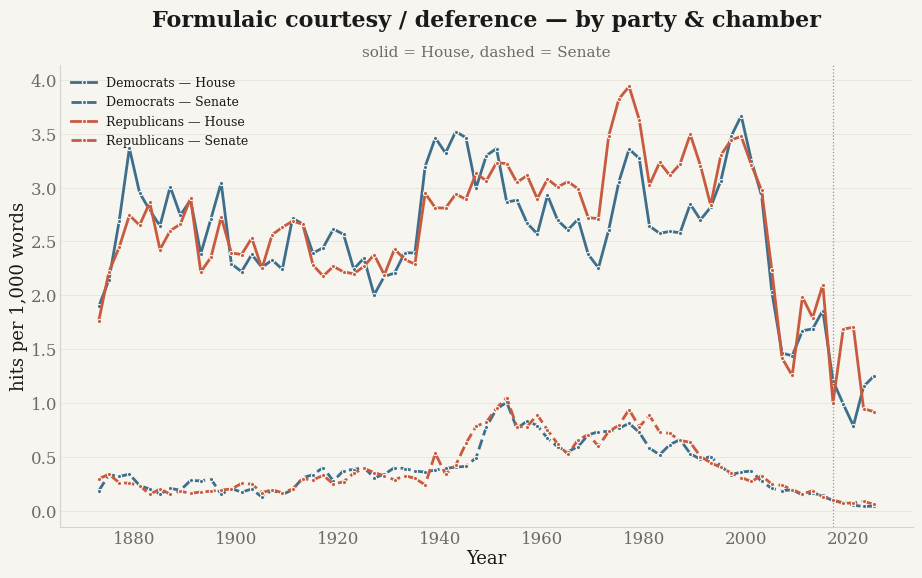

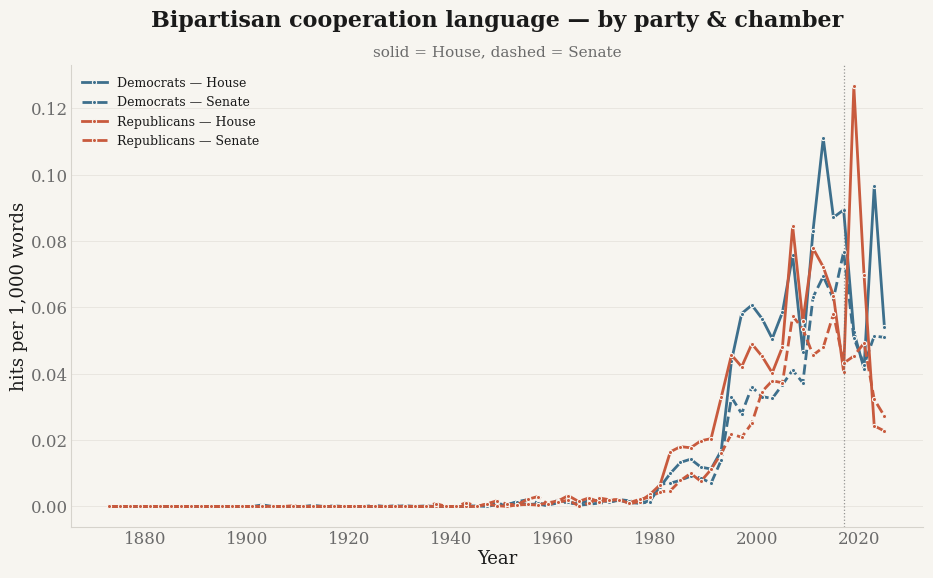

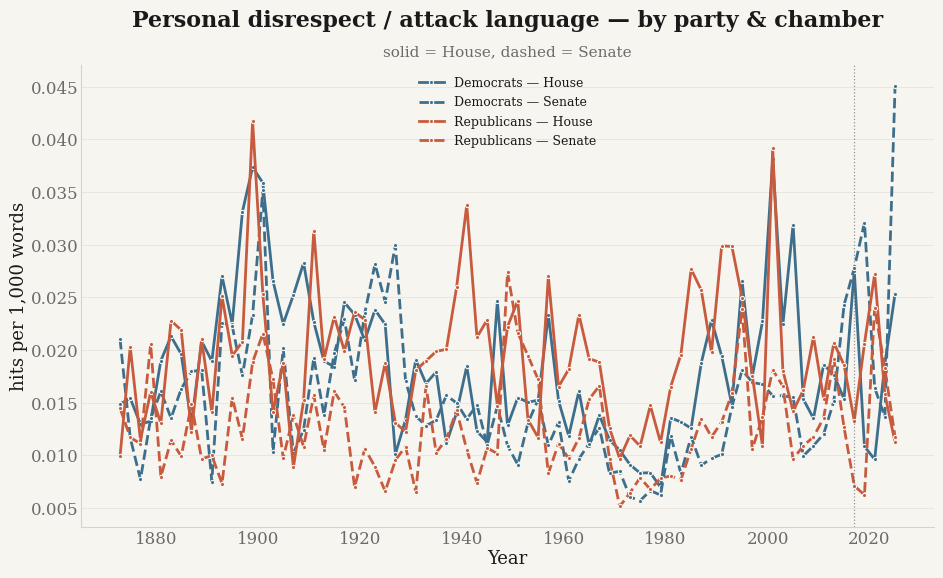

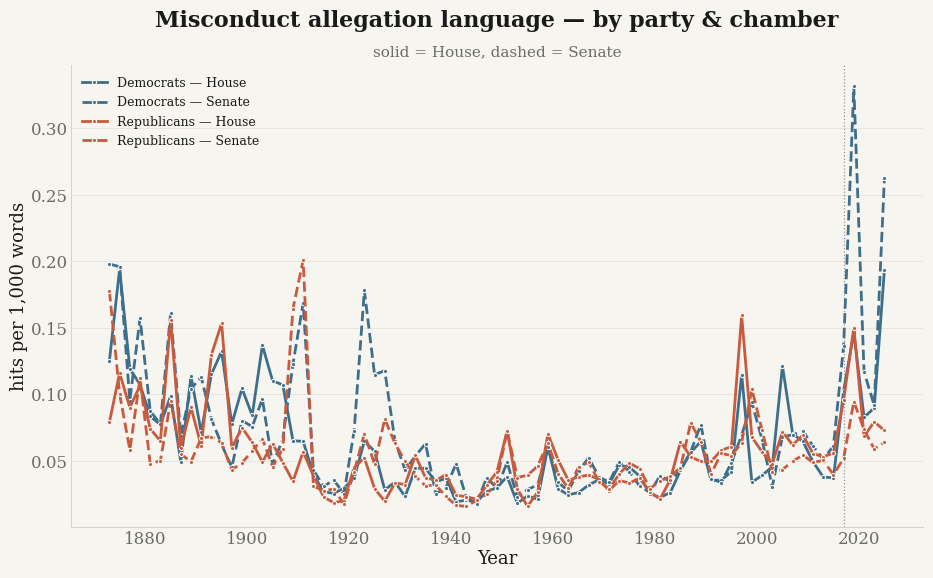

In [4]:
CHAM_STYLE = {"house": "-", "senate": "--"}
CHAM_LABEL = {"house": "House", "senate": "Senate"}

gc = _by_year_chamber_party(floor)

def plot_by_chamber(metric, title, ylabel="hits per 1,000 words"):
    fig, ax = charts.new_figure(figsize=(11, 6))
    for p in ("D","R"):
        for ch in ("house","senate"):
            sub = gc[(gc.party==p) & (gc.chamber==ch)].sort_values("year")
            if sub.empty: continue
            charts.line(ax, sub["year"], sub[metric], color=theme.PARTY_COLORS[p],
                        label=f"{theme.PARTY_LABELS[p]} — {CHAM_LABEL[ch]}",
                        linestyle=CHAM_STYLE[ch], linewidth=2.0, markersize=3)
    charts.marker_line(ax, 2017)
    charts.style_axes(ax, f"{title} — by party & chamber", "Year", ylabel,
                      subtitle="solid = House, dashed = Senate")
    ax.legend(loc="best", frameon=False, labelcolor=theme.TEXT, fontsize=9)
    plt.show()

plot_by_chamber("formal_courtesy_per_1k", "Formulaic courtesy / deference")
plot_by_chamber("cooperation_per_1k", "Bipartisan cooperation language")
plot_by_chamber("hostility_per_1k", "Personal disrespect / attack language")
plot_by_chamber("misconduct_per_1k", "Misconduct allegation language")

## 3. Plot any metric by party (overall)

Change `METRIC` to any `*_per_1k` column and re-run.

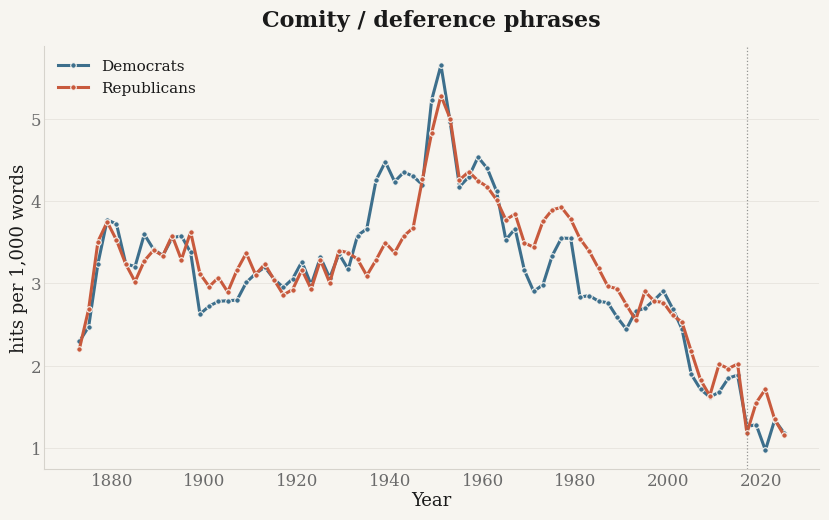

In [5]:
def plot_metric(metric, title, ylabel="hits per 1,000 words", parties=("D","R")):
    fig, ax = charts.new_figure(figsize=(10, 5.5))
    for p in parties:
        sub = g[g.party == p].sort_values("year")
        charts.line(ax, sub["year"], sub[metric], color=theme.PARTY_COLORS[p],
                    label=theme.PARTY_LABELS[p])
    charts.marker_line(ax, 2017)  # hein -> GovInfo source boundary
    charts.style_axes(ax, title, "Year", ylabel)
    ax.legend(loc="best", frameon=False, labelcolor=theme.TEXT)
    plt.show()
    return fig

METRIC = "comity_per_1k"
plot_metric(METRIC, "Comity / deference phrases");

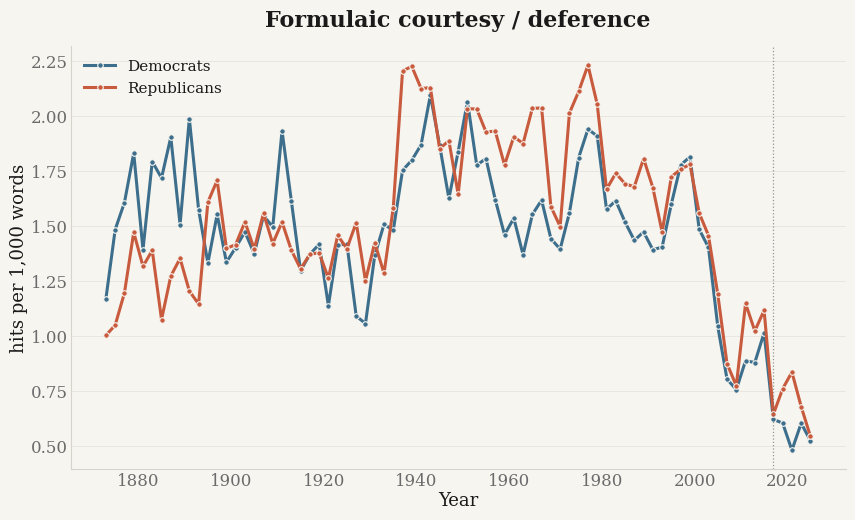

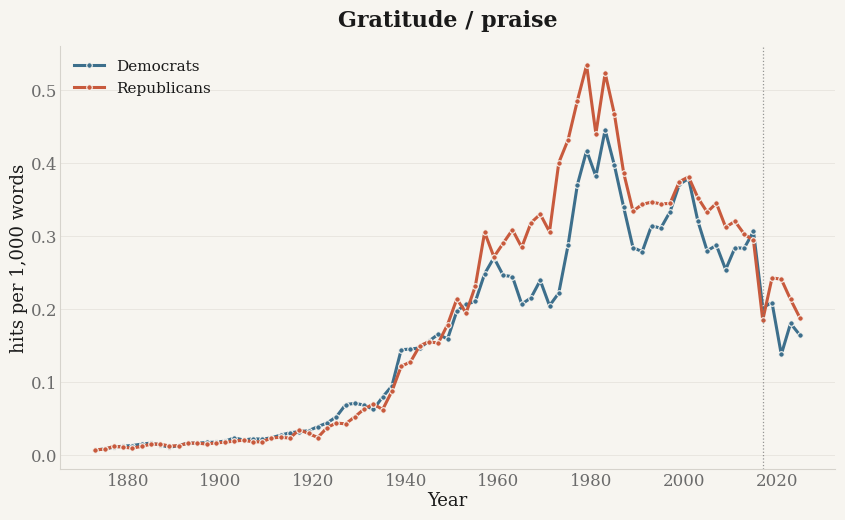

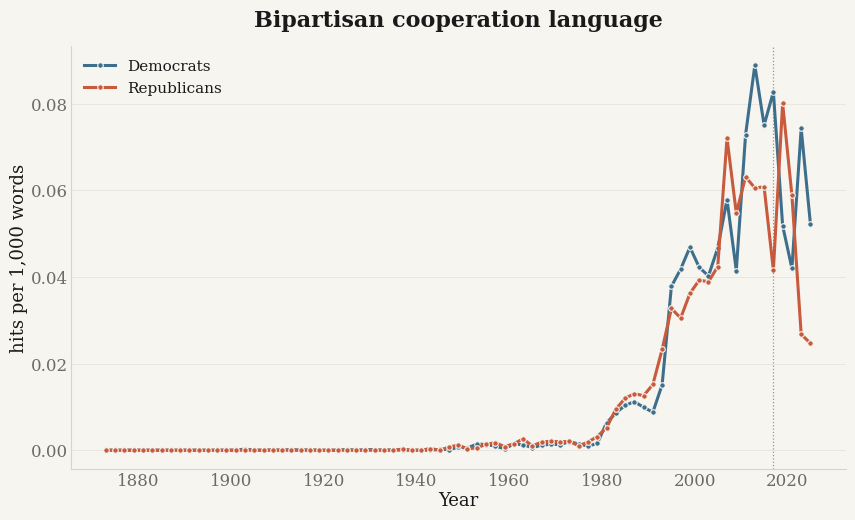

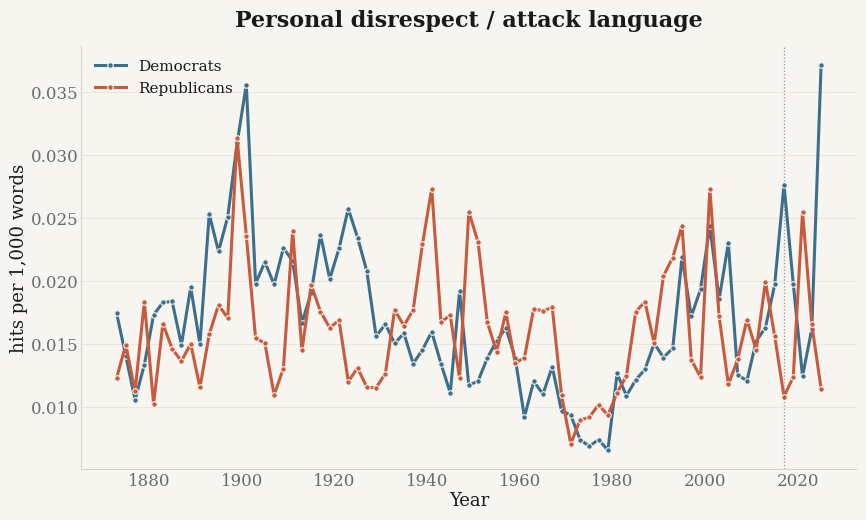

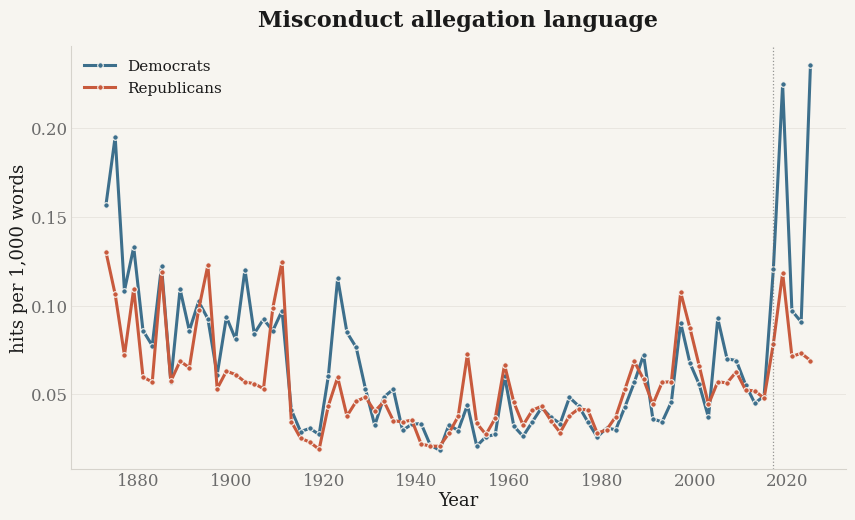

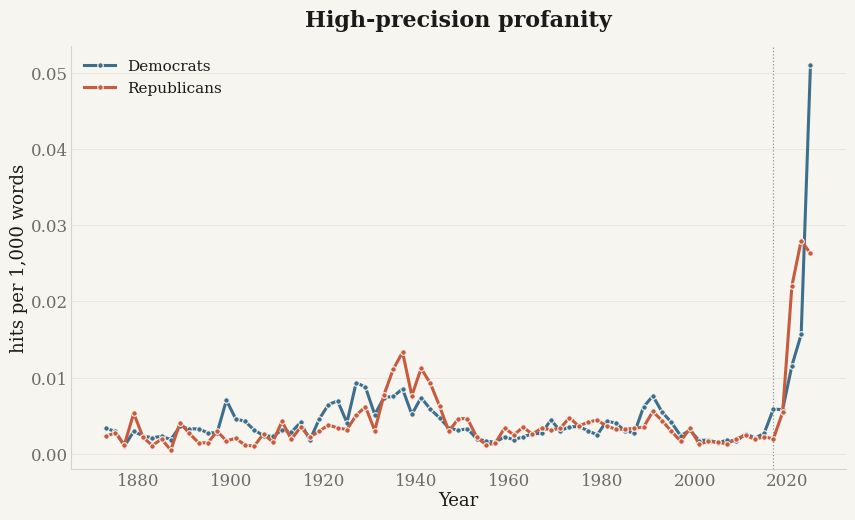

In [6]:
# The six headline panels at a glance.
for metric, title in [
    ("formal_courtesy_per_1k", "Formulaic courtesy / deference"),
    ("gratitude_praise_per_1k", "Gratitude / praise"),
    ("cooperation_per_1k", "Bipartisan cooperation language"),
    ("hostility_per_1k", "Personal disrespect / attack language"),
    ("misconduct_per_1k", "Misconduct allegation language"),
    ("profanity_per_1k", "High-precision profanity"),
]:
    plot_metric(metric, title);

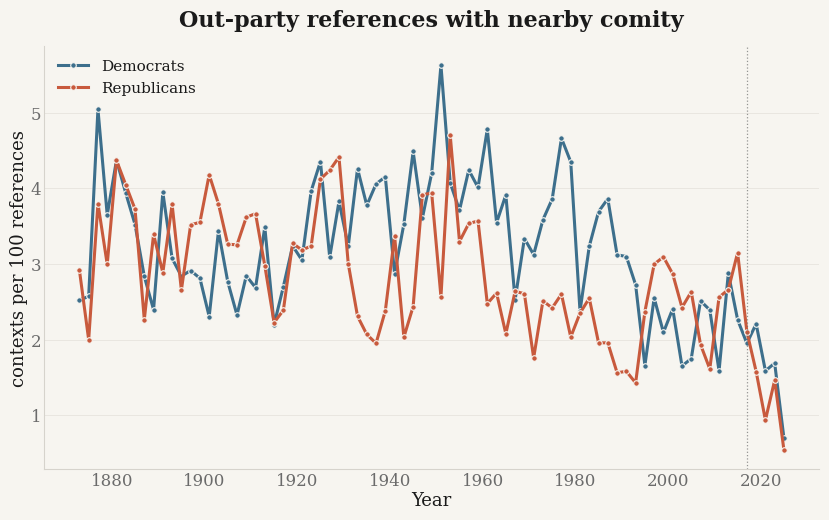

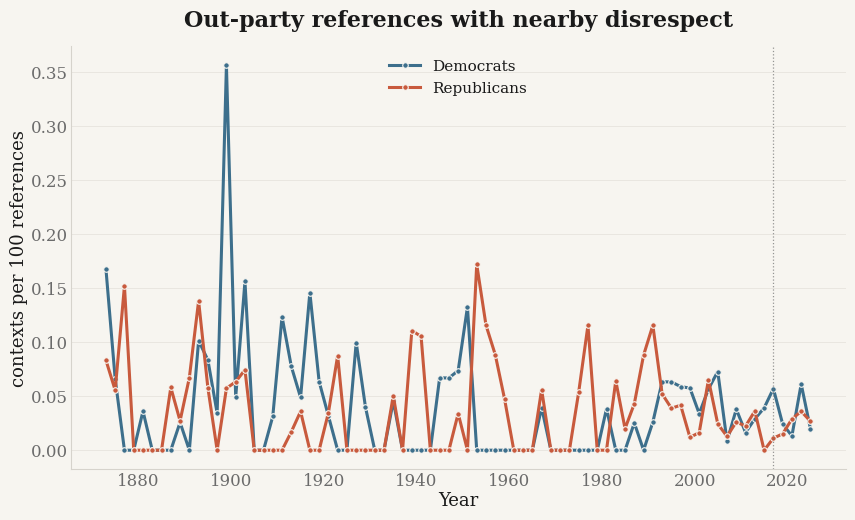

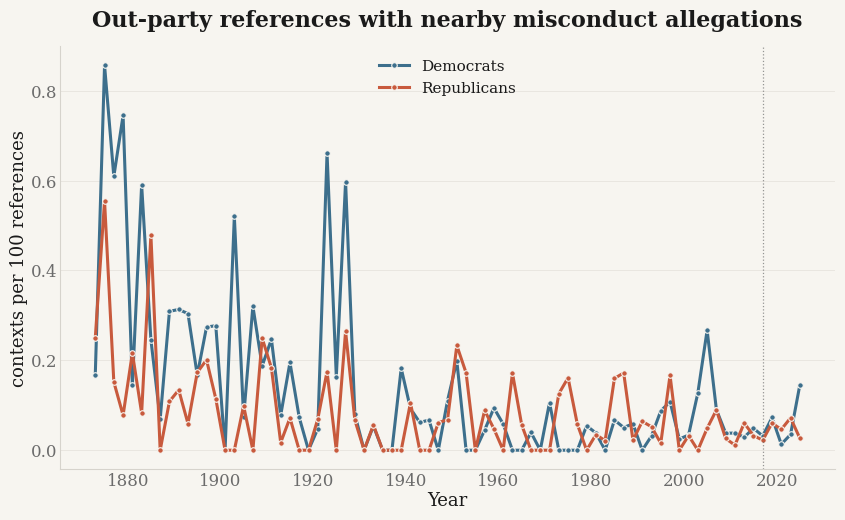

In [7]:
# Context-normalized cross-party diagnostics: share of out-party references whose
# ±200-character source window contains each language category.
for metric, title in [
    ("outgroup_comity_contexts_per_100_refs", "Out-party references with nearby comity"),
    ("outgroup_hostility_contexts_per_100_refs", "Out-party references with nearby disrespect"),
    ("outgroup_misconduct_contexts_per_100_refs", "Out-party references with nearby misconduct allegations"),
]:
    plot_metric(metric, title, ylabel="contexts per 100 references");

## 4. Toxicity — are we doing it right?

"Toxicity" here is shorthand for disclosed signals: personal disrespect + profanity rates and
**VADER** negative sentiment. Two methodological points we get right:

1. **Sentence-level VADER.** VADER's `compound` score saturates on long text, so scoring a whole
   speech (or a fixed truncation of it) is biased. `Scorers._sentiment` splits each turn into
   sentences, scores each, and averages — the granularity VADER is designed for — and reports the
   mean **negative-affect share**.
2. **Word-weighted rates.** Lexicon counts are normalised per 1,000 words, never compared as raw
   counts across eras of differing verbosity.

Below we score a real sample of source turns and inspect whether lexical signals and VADER agree.
Correlation is a diagnostic, not proof that either measure is ground truth.

In [8]:
from analysis.score.scorers import Scorers

TURN_FILES = sorted(glob.glob(str(ROOT / "data" / "interim" / "turns" / "*.parquet")))
assert TURN_FILES, "No turn parquet files; run the ingest step first."

# Sample recent turns (bulk GovInfo if present, else the newest available file).
recent = [f for f in TURN_FILES if "govinfo_bulk_" in f] or TURN_FILES[-1:]
sample = (pd.read_parquet(recent[-1], columns=["party","text","is_procedural"])
            .query("~is_procedural and text.str.len() > 0", engine="python")
            .sample(2000, random_state=0))

scorer = Scorers(use_sentiment=True)   # VADER on (this smaller sample only)
scored = sample.assign(**pd.DataFrame(
    [scorer.score_turn(t, p) for t, p in zip(sample.text, sample.party)],
    index=sample.index)[["n_words","hostility_hits","profanity_hits","sentiment","neg_share"]])
scored["hostility_per_1k"] = 1000*scored.hostility_hits/scored.n_words.clip(lower=1)
scored["profanity_per_1k"] = 1000*scored.profanity_hits/scored.n_words.clip(lower=1)
scored[["party","n_words","hostility_per_1k","profanity_per_1k","sentiment","neg_share"]].describe()

,n_words,hostility_per_1k,profanity_per_1k,sentiment,neg_share
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,404.957500,0.007253,0.007362,0.101367,0.023144
std,4283.850638,0.172831,0.258073,0.169288,0.049451
min,1.000000,0.000000,0.000000,-0.834500,0.000000
25%,21.000000,0.000000,0.000000,0.000000,0.000000
50%,62.000000,0.000000,0.000000,0.057496,0.000000
75%,270.250000,0.000000,0.000000,0.194526,0.028572
max,187818.000000,6.329114,11.363636,0.794400,0.767000


In [9]:
# Do the independent negativity signals agree? (lexical hostility/profanity vs VADER)
corr = scored[["hostility_per_1k","profanity_per_1k","neg_share","sentiment"]].corr(method="spearman")
print("Spearman correlations among negativity signals:")
try:
    display(corr.round(2))          # rich table in Jupyter
except NameError:
    print(corr.round(2))            # plain output elsewhere
print("\nInterpret correlations descriptively. Weak agreement means the signals capture different "
      "facets; even strong agreement would not establish accuracy.")

Spearman correlations among negativity signals:


,hostility_per_1k,profanity_per_1k,neg_share,sentiment
hostility_per_1k,1.00,-0.00,0.09,-0.02
profanity_per_1k,-0.00,1.00,0.08,-0.07
neg_share,0.09,0.08,1.00,-0.12
sentiment,-0.02,-0.07,-0.12,1.00



Interpret correlations descriptively. Weak agreement means the signals capture different facets; even strong agreement would not establish accuracy.


## 5. Optional: validate against a real toxicity model (Detoxify)

The cell below is **optional and heavy** (installs `torch` + `transformers` and downloads a
model). It runs the Detoxify `original` classifier on a small sample and correlates its
`toxicity` probability with our lexical proxy. A positive correlation is evidence the fast
lexical measure tracks a modern toxicity model. That is a robustness diagnostic, not validation
against independent human ground truth.

Uncomment and run only if you want the validation (it does not affect the pipeline).

In [10]:
# --- OPTIONAL: real transformer toxicity validation (slow; needs internet + torch) ---
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "detoxify"], check=True)
# from detoxify import Detoxify
# val = scored.sample(200, random_state=1).copy()
# tox = Detoxify("original").predict(list(val.text.str.slice(0, 2000)))["toxicity"]
# val["detoxify_toxicity"] = tox
# print("Spearman(lexical hostility/1k, Detoxify toxicity):",
#       round(val["hostility_per_1k"].corr(val["detoxify_toxicity"], method="spearman"), 3))
# print("Spearman(VADER neg_share,     Detoxify toxicity):",
#       round(val["neg_share"].corr(val["detoxify_toxicity"], method="spearman"), 3))
print("Optional Detoxify validation cell — uncomment the lines above to run it.")

Optional Detoxify validation cell — uncomment the lines above to run it.


## 6. Caveats

- **Lexicons are literal.** They miss sarcasm, many forms of negation, and **quotation** — a
  member reading an opponent's words is scored as if they were their own. Profanity/attacks on
  the floor also often appear inside quoted material.
- **VADER is lexical**, tuned for modern English; 19th-century phrasing is out-of-distribution.
- **Source discontinuity at 2017** (hein → GovInfo) — the dotted line on every chart. Treat
  cross-boundary jumps cautiously; compare within-source trends.
- **Segmentation error** on the GovInfo side (regex speaker splitting) is measured but non-zero.
- **Party = speaker's party**, not the target's; "directed" measures use a text window around
  out-group references. They are labelled "near out-party references" because proximity alone
  does not prove who is being addressed.
- **Model-assisted validation is not human ground truth.** Completed rubric grading uses only real,
  blinded source passages, two independent model passes, disagreement adjudication, confidence,
  rationale, and preserved `turn_id` provenance.